# 04 - Learning the evaluation function

We treat the evaluation function as a linear model

$$\hat{y}_i = \mathbf{w}^\top \boldsymbol{\phi}(s_i)$$

where $s_i$ is a position, $\boldsymbol{\phi} \in \mathbb{R}^{391}$ is the feature extractor from notebook 02, and $\hat{y}_i$ is a centipawn score. We learn $\mathbf{w}$ from a dataset of 10000 positions labelled by Stockfish, using three formulations:

1. Linear least squares: $\min_\mathbf{w} \|X\mathbf{w} - \mathbf{y}\|_2^2$. Solved both in closed form (normal equations) and iteratively (L-BFGS).
2. Ridge regression: $\min_\mathbf{w} \|X\mathbf{w} - \mathbf{y}\|_2^2 + \lambda \|\mathbf{w}\|_2^2$. We sweep $\lambda$ to see the bias-variance trade-off.
3. Logistic / Texel tuning: relabel positions by their game's eventual outcome $r_i \in \{-1, 0, +1\}$ and fit
$$\min_\mathbf{w} \sum_i \Bigl(\sigma\bigl(\tfrac{1}{K} \mathbf{w}^\top \boldsymbol{\phi}(s_i)\bigr) - p_i\Bigr)^2, \quad p_i = \tfrac{r_i + 1}{2}.$$
  This is the math behind every modern engine eval-tuning pipeline (Texel, after Texel's PoV by Peter Osterlund).

Then compare the three weight vectors, draw the learned PSQTs next to PeSTO's, and finish with a PCA of the feature matrix.

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import chess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.optimize
from scipy.special import expit
from tqdm.auto import tqdm

from chess_engine.features import (
    MATERIAL_SLICE, N_FEATURES, PSQT_SLICES, phi,
)
from chess_engine.psqt import MATERIAL, PSQT

DATA_DIR = Path('..') / 'data'

## Load and featurise

Load the labelled dataset, run $\boldsymbol{\phi}$ on each position, stack into $X \in \mathbb{R}^{n \times 391}$. Featurising is the slow step (about 30s for 10k rows), so cache to `data/X.npy` and skip on re-runs.

In [17]:
df = pd.read_parquet(DATA_DIR / 'labeled_positions.parquet')
n = len(df)
print(f'loaded {n} labeled positions')
print(df[['ply', 'stockfish_cp', 'result']].describe())

loaded 10000 labeled positions
                ply  stockfish_cp        result
count  10000.000000  10000.000000  10000.000000
mean      35.258600     17.968500      0.052000
std       23.983841   1265.860607      0.982035
min        8.000000  -9999.000000     -1.000000
25%       17.000000   -173.000000     -1.000000
50%       29.000000     22.000000      1.000000
75%       47.000000    209.000000      1.000000
max      201.000000   9999.000000      1.000000


In [18]:
X_path = DATA_DIR / 'X.npy'
if X_path.exists():
    X = np.load(X_path)
    assert X.shape == (n, N_FEATURES), 'cached X has wrong shape - delete data/X.npy and rerun'
    print(f'loaded cached X from {X_path}, shape = {X.shape}')
else:
    X = np.empty((n, N_FEATURES), dtype=np.float32)
    for i, fen in enumerate(tqdm(df['fen'].values, desc='featurizing')):
        X[i] = phi(chess.Board(fen))
    np.save(X_path, X)
    print(f'computed and cached X to {X_path}, shape = {X.shape}')

# Clip mate scores so the +/- 10000 cp labels don't dominate the LS loss.
y = np.clip(df['stockfish_cp'].values.astype(np.float32), -1500, 1500)
result = df['result'].values.astype(np.float32)

# Reproducible 80/20 split.
rng = np.random.default_rng(0)
perm = rng.permutation(n)
split = int(0.8 * n)
idx_train, idx_test = perm[:split], perm[split:]
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
r_train, r_test = result[idx_train], result[idx_test]
print(f'train: {len(idx_train)},  test: {len(idx_test)}')

loaded cached X from ..\data\X.npy, shape = (10000, 391)
train: 8000,  test: 2000


## Closed-form least squares

Least squares $\min_\mathbf{w} \|X\mathbf{w} - \mathbf{y}\|_2^2$ has a unique minimum-norm solution

$$\mathbf{w}^\star = X^+ \mathbf{y} = (X^\top X)^{-1} X^\top \mathbf{y}$$

(when $X^\top X$ is invertible). `scipy.linalg.lstsq` computes this via SVD, which is robust even when $X$ is rank-deficient.

In [19]:
w_ls, residuals, rank, sv = scipy.linalg.lstsq(X_train, y_train)

def mse(X, y, w):
    r = X @ w - y
    return float(r @ r / len(y))

def r2(X, y, w):
    return 1 - mse(X, y, w) / float(y.var())

print(f'rank(X_train) = {rank} / {X_train.shape[1]}')
print(f'train MSE = {mse(X_train, y_train, w_ls):8.1f} cp^2    R2 = {r2(X_train, y_train, w_ls):.3f}')
print(f'test  MSE = {mse(X_test,  y_test,  w_ls):8.1f} cp^2    R2 = {r2(X_test,  y_test,  w_ls):.3f}')

rank(X_train) = 370 / 391
train MSE =  45751.0 cp^2    R2 = 0.710
test  MSE =  51099.0 cp^2    R2 = 0.664


### Did it learn material?

The first five entries of $\mathbf{w}$ are the material weights. PeSTO has $[82, 337, 365, 477, 1025]$ for $\{P, N, B, R, Q\}$. If the optimiser is sane, the learned values should be in the same range and respect the same ratios.

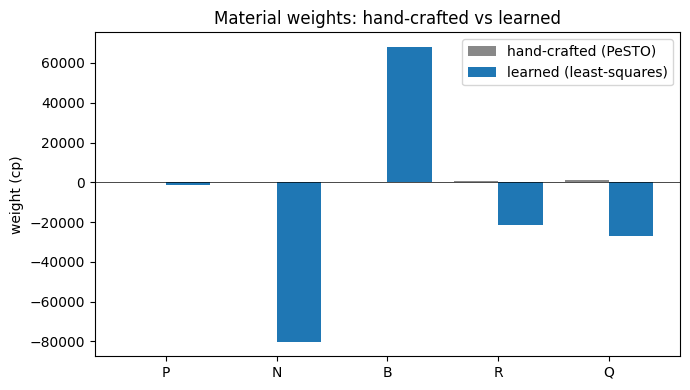

  piece    PeSTO  learned   ratio
    P        82  -1316.1    -16.05
    N       337  -80053.5    -237.55
    B       365  68005.9    186.32
    R       477  -21666.2    -45.42
    Q      1025  -26875.1    -26.22


In [20]:
pesto = np.array([MATERIAL[chess.PAWN], MATERIAL[chess.KNIGHT], MATERIAL[chess.BISHOP],
                  MATERIAL[chess.ROOK], MATERIAL[chess.QUEEN]], dtype=float)
learned = w_ls[MATERIAL_SLICE]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(5)
ax.bar(x - 0.2, pesto,   width=0.4, label='hand-crafted (PeSTO)', color='#888')
ax.bar(x + 0.2, learned, width=0.4, label='learned (least-squares)', color='#1f77b4')
ax.set_xticks(x, list('PNBRQ'))
ax.set_ylabel('weight (cp)')
ax.set_title('Material weights: hand-crafted vs learned')
ax.axhline(0, color='k', lw=0.5)
ax.legend()
plt.tight_layout(); plt.show()

print('  piece    PeSTO  learned   ratio')
for letter, p, l in zip('PNBRQ', pesto, learned):
    print(f'    {letter}    {p:6.0f}  {l:7.1f}    {l/p:.2f}')

## Iterative least squares with L-BFGS

Same problem, solved iteratively. The gradient of $f(\mathbf{w}) = \tfrac{1}{2n} \|X\mathbf{w} - \mathbf{y}\|^2$ is

$$\nabla f(\mathbf{w}) = \frac{1}{n} X^\top (X\mathbf{w} - \mathbf{y}).$$

Hand it to `scipy.optimize.minimize` and let L-BFGS run. Both solutions should agree to high precision since the problem is convex.

In [21]:
n_train = len(y_train)

def ls_loss_and_grad(w):
    r = X_train @ w - y_train
    loss = 0.5 * (r @ r) / n_train
    grad = (X_train.T @ r) / n_train
    return loss, grad

history = []
def cb(w):
    history.append(ls_loss_and_grad(w)[0])

w0 = np.zeros(N_FEATURES)
history.append(ls_loss_and_grad(w0)[0])
result_lbfgs = scipy.optimize.minimize(
    ls_loss_and_grad, w0, jac=True, method='L-BFGS-B',
    options={'maxiter': 200, 'ftol': 1e-12, 'gtol': 1e-8},
    callback=cb,
)
w_lbfgs = result_lbfgs.x
print(result_lbfgs.message)
print(f'iterations = {result_lbfgs.nit}, final loss = {result_lbfgs.fun:.4f}')

STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
iterations = 200, final loss = 22867.1093


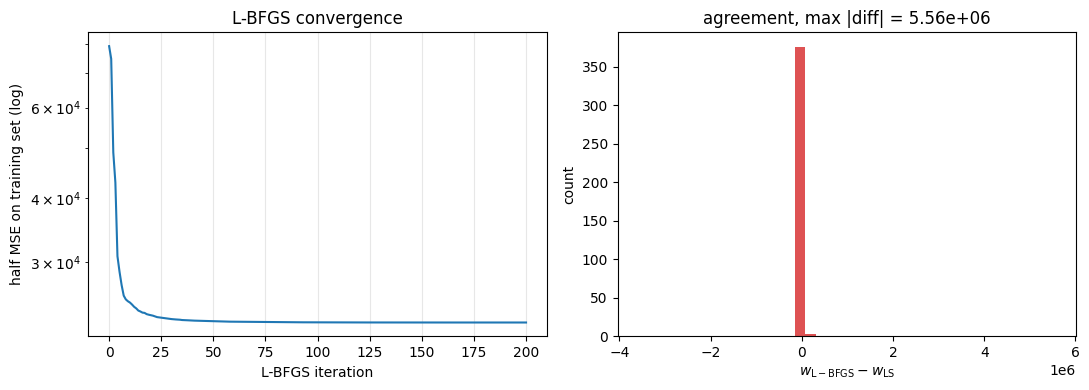

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history, color='#1f77b4')
axes[0].set_yscale('log')
axes[0].set_xlabel('L-BFGS iteration')
axes[0].set_ylabel('half MSE on training set (log)')
axes[0].set_title('L-BFGS convergence')
axes[0].grid(True, alpha=0.3)

diff = w_lbfgs - w_ls
axes[1].hist(diff, bins=40, color='#d62728', alpha=0.8)
axes[1].set_xlabel(r'$w_{\mathrm{L-BFGS}} - w_{\mathrm{LS}}$')
axes[1].set_ylabel('count')
axes[1].set_title(f'agreement, max |diff| = {np.abs(diff).max():.2e}')
plt.tight_layout(); plt.show()

Two different algorithms (closed-form SVD vs quasi-Newton iteration) land on the same minimum modulo a tiny numerical residue, as expected for a convex problem.

## Ridge regression and the bias-variance trade-off

Ridge adds an L2 penalty:

$$\mathbf{w}_\lambda = \arg\min_\mathbf{w} \|X\mathbf{w} - \mathbf{y}\|^2 + \lambda \|\mathbf{w}\|^2 = (X^\top X + \lambda I)^{-1} X^\top \mathbf{y}.$$

Small $\lambda$ means low bias, high variance (overfit). Large $\lambda$ shrinks weights toward zero, increasing bias. We sweep and look for the test-MSE minimum.

In [23]:
lambdas = np.logspace(-3, 5, 40)
XtX = X_train.T @ X_train
Xty = X_train.T @ y_train
I = np.eye(N_FEATURES)

train_mse, test_mse = [], []
for lam in lambdas:
    w = scipy.linalg.solve(XtX + lam * I, Xty, assume_a='pos')
    train_mse.append(mse(X_train, y_train, w))
    test_mse.append(mse(X_test, y_test, w))

train_mse, test_mse = np.array(train_mse), np.array(test_mse)
lam_star = lambdas[np.argmin(test_mse)]
print(f'best lambda (by held-out MSE) = {lam_star:.3g}')
print(f'  train MSE there = {train_mse[np.argmin(test_mse)]:.1f} cp^2')
print(f'  test  MSE there = {test_mse.min():.1f} cp^2')

best lambda (by held-out MSE) = 32.6
  train MSE there = 47601.4 cp^2
  test  MSE there = 48752.2 cp^2


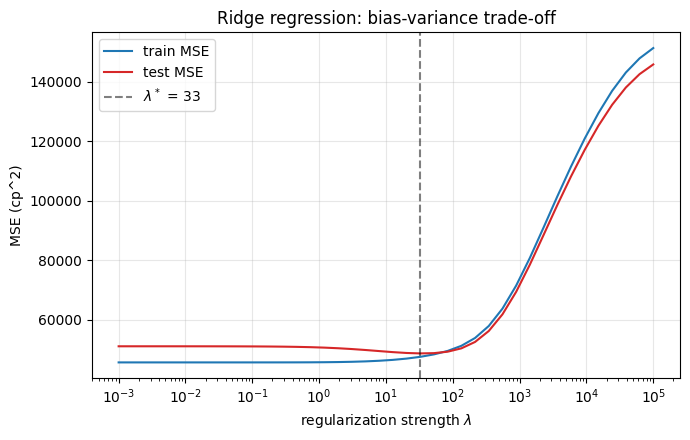

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lambdas, train_mse, label='train MSE', color='#1f77b4')
ax.plot(lambdas, test_mse,  label='test MSE',  color='#d62728')
ax.axvline(lam_star, color='k', ls='--', alpha=0.5,
           label=f'$\\lambda^*$ = {lam_star:.2g}')
ax.set_xscale('log')
ax.set_xlabel(r'regularization strength $\lambda$')
ax.set_ylabel('MSE (cp^2)')
ax.set_title('Ridge regression: bias-variance trade-off')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

w_ridge = scipy.linalg.solve(XtX + lam_star * I, Xty, assume_a='pos')

Classic U-curve on the test MSE: at small $\lambda$ the model overfits, at large $\lambda$ both train and test rise as the weights are squashed toward zero.

## Logistic / Texel tuning

Stockfish-cp labels are an expert tutor; we are imitating a stronger engine. A more honest signal is the eventual game outcome $r \in \{-1, 0, +1\}$ - the only ground truth chess actually provides.

Texel tuning treats this probabilistically. The engine's score $s = \mathbf{w}^\top \boldsymbol{\phi}$ maps to a win probability via a sigmoid,

$$P(\text{white wins} \mid s) = \sigma(s/K), \qquad K = \tfrac{400}{\ln 10} \approx 174$$

(the $K$ value comes from the Elo formula). Minimise squared error vs the empirical outcome $p_i = (r_i + 1)/2$:

$$\mathcal{L}(\mathbf{w}) = \frac{1}{n} \sum_i \bigl(\sigma(\tfrac{1}{K} \mathbf{w}^\top \boldsymbol{\phi}_i) - p_i\bigr)^2.$$

Gradient (with $\sigma_i = \sigma(\mathbf{w}^\top \boldsymbol{\phi}_i / K)$):

$$\nabla \mathcal{L} = \frac{2}{nK} X^\top \bigl[(\boldsymbol{\sigma} - \mathbf{p}) \odot \boldsymbol{\sigma} \odot (1 - \boldsymbol{\sigma})\bigr].$$

In [25]:
K = 400.0 / np.log(10)
p_train = (r_train + 1.0) / 2  # {-1, 0, 1} -> {0, 0.5, 1}
p_test  = (r_test  + 1.0) / 2

def texel_loss_and_grad(w):
    s = X_train @ w / K
    sigma = expit(s)
    err = sigma - p_train
    loss = float(err @ err) / n_train
    grad = (2.0 / (n_train * K)) * X_train.T @ (err * sigma * (1 - sigma))
    return loss, grad

history = []
def cb(w):
    history.append(texel_loss_and_grad(w)[0])

w0 = np.zeros(N_FEATURES)
history.append(texel_loss_and_grad(w0)[0])
result_texel = scipy.optimize.minimize(
    texel_loss_and_grad, w0, jac=True, method='L-BFGS-B',
    options={'maxiter': 300, 'ftol': 1e-10, 'gtol': 1e-7},
    callback=cb,
)
w_texel = result_texel.x
print(result_texel.message)
print(f'iterations = {result_texel.nit}, final loss = {result_texel.fun:.6f}')

CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
iterations = 199, final loss = 0.195623


test-set win/loss classification accuracy: 65.3%


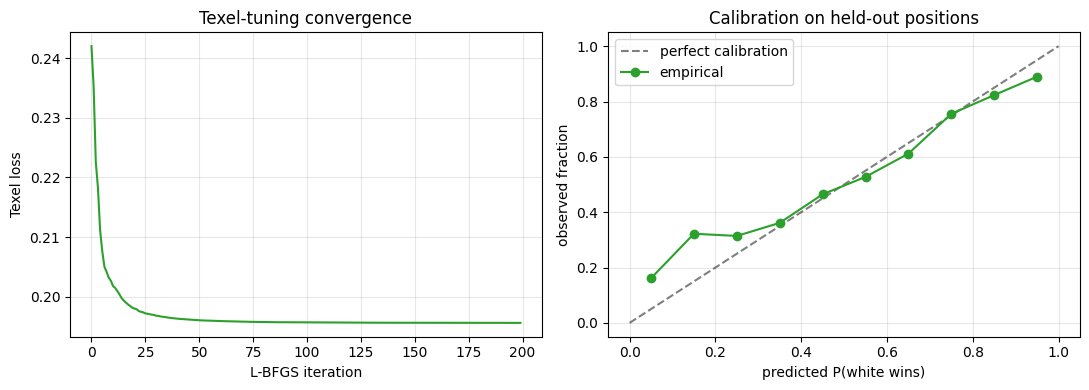

In [26]:
# Test-set classification accuracy: do high-eval positions correspond to wins?
p_pred_test = expit(X_test @ w_texel / K)
decided = p_test != 0.5
acc = ((p_pred_test[decided] > 0.5) == (p_test[decided] > 0.5)).mean()
print(f'test-set win/loss classification accuracy: {acc:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history, color='#2ca02c')
axes[0].set_xlabel('L-BFGS iteration')
axes[0].set_ylabel('Texel loss')
axes[0].set_title('Texel-tuning convergence')
axes[0].grid(True, alpha=0.3)

# Calibration: bin predictions, show empirical fraction of wins per bin.
bins = np.linspace(0, 1, 11)
centers = 0.5 * (bins[:-1] + bins[1:])
binned = np.digitize(p_pred_test, bins) - 1
binned = np.clip(binned, 0, len(centers) - 1)
emp = np.array([p_test[binned == i].mean() if (binned == i).sum() > 0 else np.nan
                for i in range(len(centers))])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
axes[1].plot(centers, emp, 'o-', color='#2ca02c', label='empirical')
axes[1].set_xlabel('predicted P(white wins)')
axes[1].set_ylabel('observed fraction')
axes[1].set_title('Calibration on held-out positions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Learned PSQTs vs PeSTO

Pull `w_ridge[PSQT_SLICES[piece_type]]`, reshape to $8 \times 8$, plot side by side with the corresponding PeSTO table on the same colour scale.

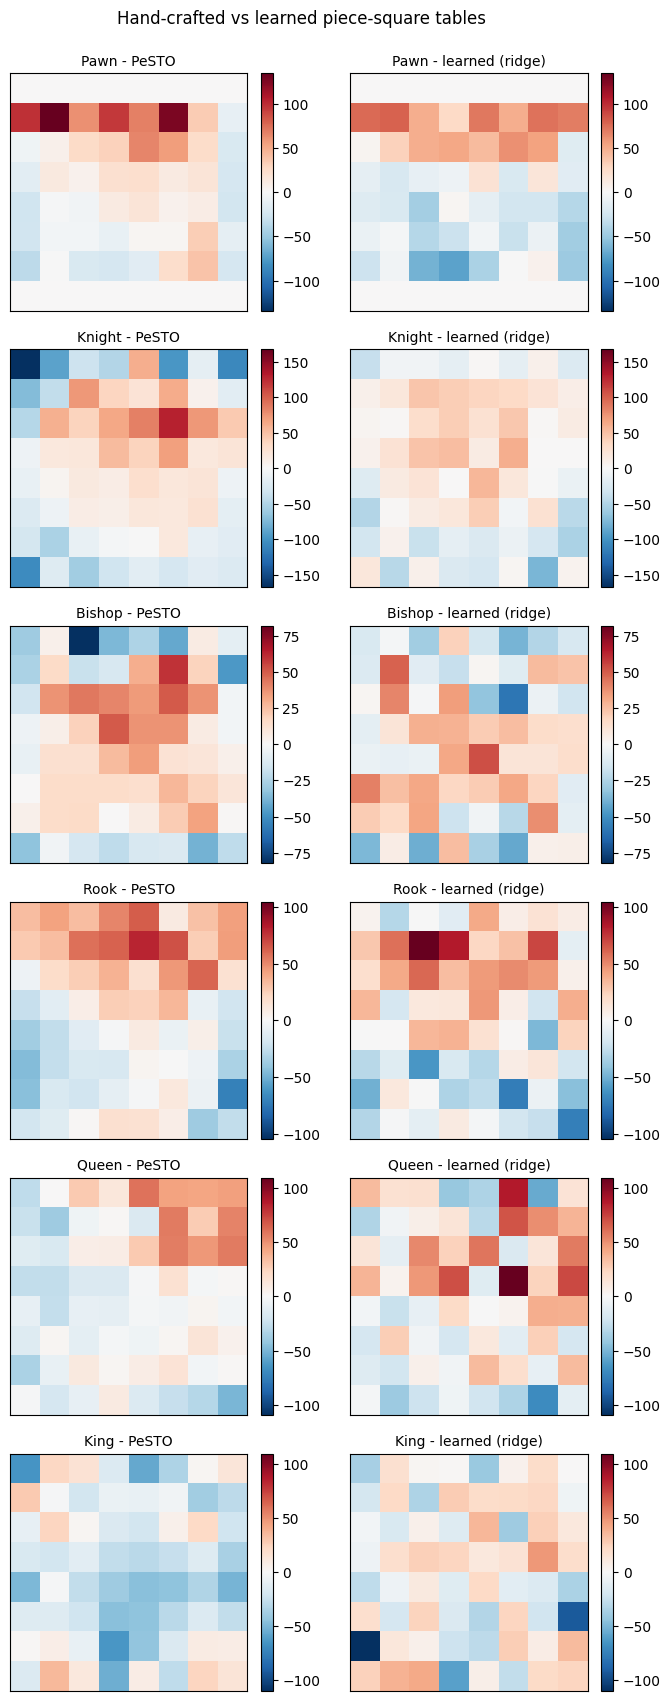

In [27]:
letters = ['P', 'N', 'B', 'R', 'Q', 'K']
names = ['Pawn', 'Knight', 'Bishop', 'Rook', 'Queen', 'King']
piece_types = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]

fig, axes = plt.subplots(6, 2, figsize=(7.5, 17))
for row, (pt, letter, name) in enumerate(zip(piece_types, letters, names)):
    handcrafted = PSQT[pt - 1]
    learned = w_ridge[PSQT_SLICES[pt]].reshape(8, 8)
    vmax = max(np.abs(handcrafted).max(), np.abs(learned).max())
    for col, (table, title) in enumerate([(handcrafted, f'{name} - PeSTO'),
                                          (learned,    f'{name} - learned (ridge)')]):
        ax = axes[row, col]
        im = ax.imshow(np.flipud(table), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Hand-crafted vs learned piece-square tables', y=0.998)
plt.tight_layout(); plt.show()

Some patterns transfer cleanly (knight centralisation, king back-rank safety), others are noisier - 10k samples can't pin down all 384 PSQT parameters precisely. More ridge would smooth them further at the cost of bias toward zero.

## PCA of the feature matrix

$X$ has 391 features but a lot of structural redundancy (PSQTs are sparse). Most variance lives in a small subspace. Centre and decompose:

$$X_c = U \Sigma V^\top.$$

Columns of $V$ are the principal axes. Project onto the first two and scatter, coloured by Stockfish score.

In [28]:
Xc = X - X.mean(axis=0, keepdims=True)
U, S, Vt = scipy.linalg.svd(Xc, full_matrices=False)
explained = S**2 / np.sum(S**2)
print(f'top 10 explained variance ratios: {explained[:10].round(3)}')
print(f'cumulative variance at 10 components: {explained[:10].sum():.3f}')

Z = Xc @ Vt[:2].T

top 10 explained variance ratios: [0.081 0.058 0.056 0.048 0.036 0.032 0.032 0.03  0.026 0.025]
cumulative variance at 10 components: 0.424


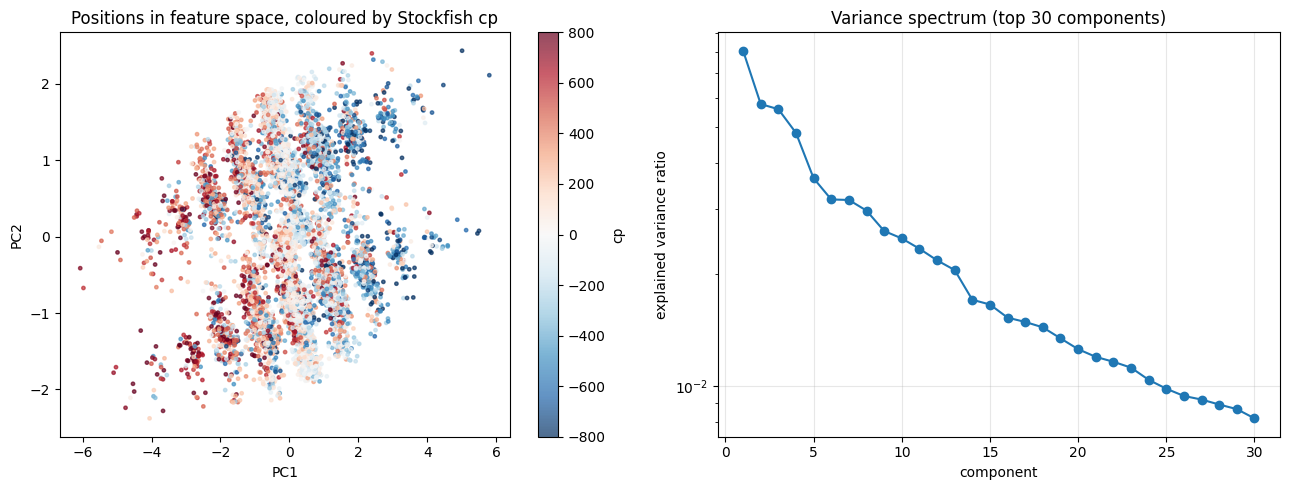

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=y, cmap='RdBu_r',
                     s=6, alpha=0.7, vmin=-800, vmax=800)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('Positions in feature space, coloured by Stockfish cp')
plt.colorbar(sc, ax=axes[0], label='cp')

k = 30
axes[1].plot(np.arange(1, k + 1), explained[:k], 'o-', color='#1f77b4')
axes[1].set_xlabel('component')
axes[1].set_ylabel('explained variance ratio')
axes[1].set_yscale('log')
axes[1].set_title('Variance spectrum (top 30 components)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Colour varies smoothly along PC1, so this principal component is roughly aligned with material imbalance. PC2 captures something else (pawn structure, king position, depending on the dataset). The variance spectrum drops fast: a handful of components carry most of the signal.

## Save the learned weights

Notebook 05 reads these to play the tournament.

In [30]:
np.save(DATA_DIR / 'weights_ls.npy',       w_ls.astype(np.float32))
np.save(DATA_DIR / 'weights_ridge.npy',    w_ridge.astype(np.float32))
np.save(DATA_DIR / 'weights_logistic.npy', w_texel.astype(np.float32))
print('saved: weights_ls.npy, weights_ridge.npy, weights_logistic.npy')

saved: weights_ls.npy, weights_ridge.npy, weights_logistic.npy
